In [5]:
import numpy as np

from scipy.stats import chi2, poisson
from scipy.integrate import quad
from scipy.optimize import brute, minimize
from scipy.fft import rfft, rfftfreq
from scipy import signal

import pywt

import matplotlib.pyplot as plt

In [6]:

# time step
dt = 1e-3

NoiseLevel = [0, 0.1, 2][0]

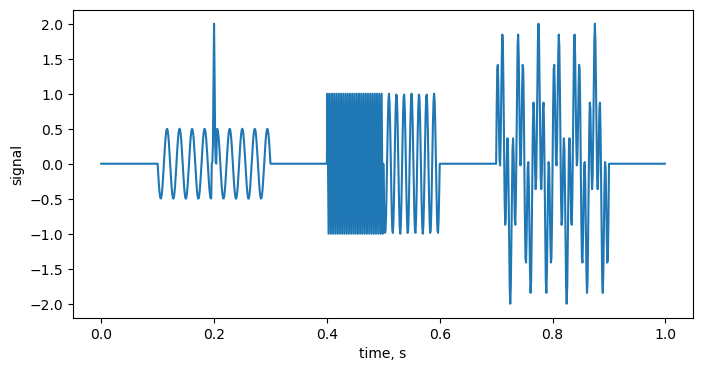

In [7]:
t = np.arange(0, 1, dt)

condlist1 = [(_[0] < t) & (t < _[1]) for _ in [[0.1, 0.3], [0.4, 0.5], [0.5, 0.6], [0.7, 0.9]]]
funclist1 = [lambda _ : 0.5 * np.sin(2*np.pi * 45*_),
             lambda _ : np.sin(2*np.pi * 250*_),
             lambda _ : np.sin(2*np.pi * 75*_),
             lambda _ : np.sin(2*np.pi * 30*_) + np.sin(2*np.pi * 110*_)]            
condlist2 = [(0.2 - 0.005 < t) & (t < 0.2 + 0.005)]
funclist2 = [lambda _ : 2 * np.exp(-((_ - 0.2)**2 / (2 * 0.001**2))) - 0.5 * np.sin(2*np.pi * 45*_)]

sig = np.piecewise(t, condlist1, funclist1) + np.piecewise(t, condlist2, funclist2)

# generating noise

sig += np.random.poisson(NoiseLevel, len(t))

plt.figure(figsize=(8, 4))
plt.plot(t, sig)
plt.xlabel('time, s')
plt.ylabel('signal')
plt.show()

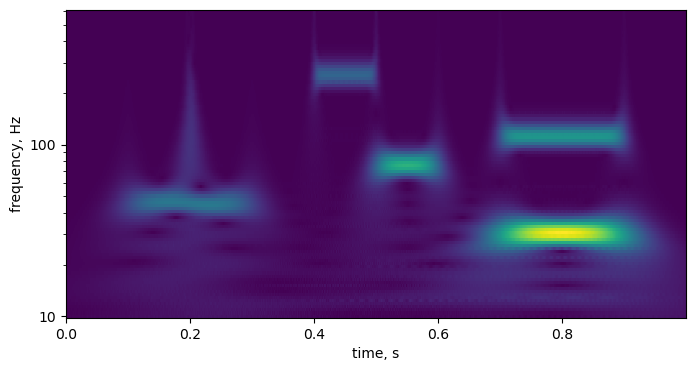

In [14]:
fs = 1 / dt
w = 10 # parameter of morlet wavelet

freqs = np.logspace(np.log10(10), np.log10(600), 100)

# Map frequencies to pywt scales
# For 'cmor', scale = center_frequency / (normalized_frequency)
# pywt.scale2frequency(wavelet, scale) * fs = freq
# Therefore: scale = center_frequency * fs / freq
wavelet = f'cmor1.5-{w/(2*np.pi)}' 
scales = pywt.scale2frequency(wavelet, 1) * fs / freqs

# Transform
# pywt.cwt returns (coefficients, frequencies)
cwtm, frequencies = pywt.cwt(sig, scales, wavelet, sampling_period=dt)

# wavelet transform (depreciated)
#widths = w*fs / (2*np.pi * freq)
#cwtm = signal.cwt(sig, signal.morlet2, widths, w=w)

plt.figure(figsize=(8, 4))

plt.pcolormesh(t, freqs, np.abs(cwtm))
plt.yscale('log')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.16g}'))
plt.xlabel('time, s')
plt.ylabel('frequency, Hz')

plt.show()